# Data Source Check: baostock vs. qlib (Yahoo-sourced) CN data

Goal: verify whether the qlib default CN dataset (Yahoo Finance-sourced, used in `alphagen1.ipynb`)
matches the baostock forward-adjusted data that the AlphaGen paper actually uses.

Run this **after** `alphagen1.ipynb` has already initialized qlib at `/root/.qlib/qlib_data/cn_data`
(the Yahoo-sourced data), so both sources are available in the same session.


## 1. Install & login to baostock

In [4]:
import sys
print(sys.version)  # should now say 3.10.x

import qlib
print("qlib version:", qlib.__version__)

3.10.20 (main, Mar 11 2026, 17:43:48) [Clang 20.1.8 ]
qlib version: 0.9.7


In [5]:
from qlib.tests.data import GetData
GetData().qlib_data(target_dir='~/.qlib/qlib_data/cn_data', region='cn', interval='1d')

2026-08-09 17:55:34.997 | WARNING  | qlib.tests.data:download:62 - The data for the example is collected from Yahoo Finance. Please be aware that the quality of the data might not be perfect. (You can refer to the original data source: https://finance.yahoo.com/lookup.)
2026-08-09 17:55:34.998 | INFO     | qlib.tests.data:download:65 - 20260809175534_qlib_data_cn_1d_latest.zip downloading......
196549632it [00:46, 4231788.33it/s]                                  
2026-08-09 17:56:21.450 | WARNING  | qlib.tests.data:_unzip:124 - will delete the old qlib data directory(features, instruments, calendars, features_cache, dataset_cache): /Users/phuongnhung/.qlib/qlib_data/cn_data


Will be deleted: 
	['/Users/phuongnhung/.qlib/qlib_data/cn_data/features', '/Users/phuongnhung/.qlib/qlib_data/cn_data/calendars', '/Users/phuongnhung/.qlib/qlib_data/cn_data/instruments']
If you do not need to delete /Users/phuongnhung/.qlib/qlib_data/cn_data, please change the <--target_dir>
Are you sure you want to delete, yes(Y/y), no (N/n): y


2026-08-09 17:57:18.463 | WARNING  | qlib.tests.data:_delete_qlib_data:150 - delete: /Users/phuongnhung/.qlib/qlib_data/cn_data/features
2026-08-09 17:57:20.044 | WARNING  | qlib.tests.data:_delete_qlib_data:150 - delete: /Users/phuongnhung/.qlib/qlib_data/cn_data/calendars
2026-08-09 17:57:20.045 | WARNING  | qlib.tests.data:_delete_qlib_data:150 - delete: /Users/phuongnhung/.qlib/qlib_data/cn_data/instruments
2026-08-09 17:57:20.046 | INFO     | qlib.tests.data:_unzip:128 - /Users/phuongnhung/.qlib/qlib_data/cn_data/20260809175534_qlib_data_cn_1d_latest.zip unzipping......
100%|████████████████████████| 31008/31008 [00:03<00:00, 8853.24it/s]


In [1]:
!pip install baostock yfinance pandas numpy matplotlib -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import baostock as bs
import pandas as pd

bs.login()

def fetch_baostock(code, start, end):
    rs = bs.query_history_k_data_plus(
        code, "date,code,open,high,low,close,volume",
        start_date=start, end_date=end, frequency="d", adjustflag="1"
    )
    rows = []
    while rs.error_code == '0' and rs.next():
        rows.append(rs.get_row_data())
    df = pd.DataFrame(rows, columns=rs.fields)
    for c in ["open","high","low","close","volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["date"] = pd.to_datetime(df["date"])
    return df.set_index("date")

bs_df = fetch_baostock("sh.600519", "2020-01-01", "2020-06-30")
bs_df.head()

login success!


,code,open,high,low,close,volume
date,,,,,,
2020-01-02,sh.600519,7321.994640,7432.733318,7244.101080,7334.976900,14809916
2020-01-03,sh.600519,7250.592210,7250.592210,6990.297897,7001.073173,13031878
2020-01-06,sh.600519,6951.091472,7094.155977,6927.983049,6997.373229,6341478
2020-01-07,sh.600519,6994.192575,7133.751870,6987.052332,7104.736519,4785359
2020-01-08,sh.600519,7043.200606,7111.032915,7027.167515,7063.258198,2500825


In [3]:
import yfinance as yf

# Moutai's Yahoo ticker is 600519.SS (Shanghai) 
yf_df = yf.download("600519.SS", start="2020-01-01", end="2020-06-30")
yf_df.head()

/var/folders/kx/d7rwb5z50bvd6bd4hfmrg0wm0000gp/T/ipykernel_25541/2536900919.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf_df = yf.download("600519.SS", start="2020-01-01", end="2020-06-30")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,600519.SS,600519.SS,600519.SS,600519.SS,600519.SS
Date,,,,,
2020-01-02,956.358032,969.103880,944.509349,954.665363,14809916
2020-01-03,912.822510,945.355556,911.417566,945.355556,13031878
2020-01-06,912.340088,924.958964,903.292822,906.305719,6341478
2020-01-07,926.338440,930.121530,910.994393,911.925340,4785359
2020-01-08,920.930420,920.930420,920.930420,920.930420,2500825


In [5]:
if isinstance(yf_df.columns, pd.MultiIndex):
    yf_df.columns = yf_df.columns.get_level_values(0)

correlation: 0.9999999999884168


<Axes: >

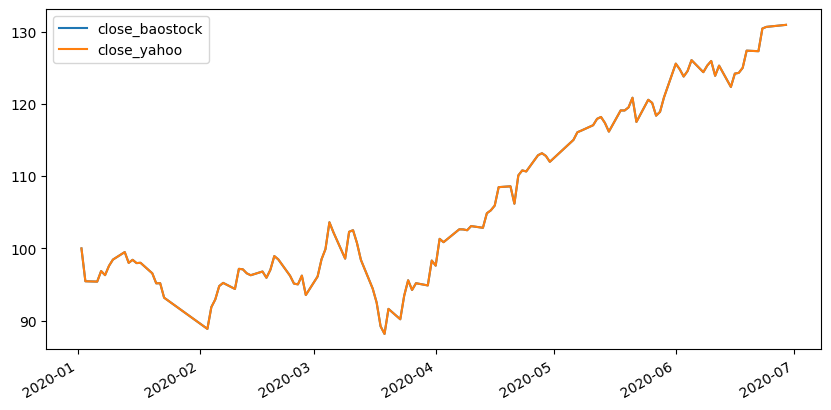

In [6]:
merged = bs_df[["close"]].join(yf_df[["Close"]], how="inner")
merged.columns = ["close_baostock", "close_yahoo"]
merged["close_baostock"] = merged["close_baostock"] / merged["close_baostock"].iloc[0] * 100
merged["close_yahoo"] = merged["close_yahoo"] / merged["close_yahoo"].iloc[0] * 100

print("correlation:", merged["close_baostock"].corr(merged["close_yahoo"]))
merged.plot(figsize=(10,5))

In [7]:
# mean % diff (on the rebased prices you already computed)
price_pct_diff = ((merged["close_baostock"] - merged["close_yahoo"]).abs() / merged["close_yahoo"]).mean() * 100
print("mean abs % diff (rebased close):", price_pct_diff, "%")

# volume comparison (raw, not rebased)
vol_merged = bs_df[["volume"]].join(yf_df[["Volume"]], how="inner")
vol_merged.columns = ["volume_baostock", "volume_yahoo"]
vol_ratio = (vol_merged["volume_baostock"] / vol_merged["volume_yahoo"]).median()
print("median volume ratio (baostock/yahoo):", vol_ratio)

# date coverage
n_common = len(merged)
n_bs_only = len(bs_df) - n_common
n_yahoo_only = len(yf_df) - n_common
print(f"common dates: {n_common}  (baostock-only: {n_bs_only}, yahoo-only: {n_yahoo_only})")

mean abs % diff (rebased close): 1.5001085338128275e-05 %
median volume ratio (baostock/yahoo): 1.0
common dates: 116  (baostock-only: 1, yahoo-only: 0)


In [8]:
sample_stocks = {
    "sh.600519": "600519.SS",  # Kweichow Moutai
    "sh.601318": "601318.SS",  # Ping An Insurance
    "sz.000001": "000001.SZ",  # Ping An Bank
    "sh.600036": "600036.SS",  # China Merchants Bank
    "sz.000651": "000651.SZ",  # Gree Electric
}

results = []
bs.login()
for bs_code, yf_code in sample_stocks.items():
    bdf = fetch_baostock(bs_code, "2020-01-01", "2020-06-30")

    ydf = yf.download(yf_code, start="2020-01-01", end="2020-06-30", progress=False)
    if isinstance(ydf.columns, pd.MultiIndex):
        ydf.columns = ydf.columns.get_level_values(0)

    m = bdf[["close", "volume"]].join(ydf[["Close", "Volume"]], how="inner")
    m.columns = ["close_bs", "volume_bs", "close_yahoo", "volume_yahoo"]

    if m.empty:
        print(f"{yf_code}: no overlap")
        continue

    bs_rebased = m["close_bs"] / m["close_bs"].iloc[0] * 100
    yahoo_rebased = m["close_yahoo"] / m["close_yahoo"].iloc[0] * 100

    results.append({
        "code": yf_code,
        "n_common_dates": len(m),
        "n_bs_only": len(bdf) - len(m),
        "n_yahoo_only": len(ydf) - len(m),
        "price_corr": bs_rebased.corr(yahoo_rebased),
        "price_pct_diff": ((bs_rebased - yahoo_rebased).abs() / yahoo_rebased).mean() * 100,
        "vol_ratio": (m["volume_bs"] / m["volume_yahoo"]).median(),
    })
bs.logout()

summary = pd.DataFrame(results)
summary


login success!


/var/folders/kx/d7rwb5z50bvd6bd4hfmrg0wm0000gp/T/ipykernel_25541/357087647.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ydf = yf.download(yf_code, start="2020-01-01", end="2020-06-30", progress=False)
/var/folders/kx/d7rwb5z50bvd6bd4hfmrg0wm0000gp/T/ipykernel_25541/357087647.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ydf = yf.download(yf_code, start="2020-01-01", end="2020-06-30", progress=False)
/var/folders/kx/d7rwb5z50bvd6bd4hfmrg0wm0000gp/T/ipykernel_25541/357087647.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ydf = yf.download(yf_code, start="2020-01-01", end="2020-06-30", progress=False)
/var/folders/kx/d7rwb5z50bvd6bd4hfmrg0wm0000gp/T/ipykernel_25541/357087647.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ydf = yf.download(yf_code, start="2020-01-01", end="2020-06-30", progress=False)
/var/folders/kx/d7rwb5z50bvd

logout success!


,code,n_common_dates,n_bs_only,n_yahoo_only,price_corr,price_pct_diff,vol_ratio
0,600519.SS,116,1,0,1.000000,0.000015,1.000000
1,601318.SS,116,1,0,1.000000,0.004197,1.000000
2,000001.SZ,116,1,0,0.997770,0.367412,1.008717
3,600036.SS,116,1,0,1.000000,0.000008,1.000000
4,000651.SZ,116,1,0,0.999944,0.036753,1.008896


In [9]:
import baostock as bs
import yfinance as yf
import pandas as pd

def fetch_baostock(code, start, end):
    rs = bs.query_history_k_data_plus(
        code,
        "date,code,open,high,low,close,volume",
        start_date=start, end_date=end,
        frequency="d",
        adjustflag="1",
    )
    rows = []
    while rs.error_code == '0' and rs.next():
        rows.append(rs.get_row_data())
    df = pd.DataFrame(rows, columns=rs.fields)
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["date"] = pd.to_datetime(df["date"])
    return df.set_index("date")

sample_stocks = {
    "sh.600519": "600519.SS",  # Kweichow Moutai
    "sh.601318": "601318.SS",  # Ping An Insurance
    "sz.000001": "000001.SZ",  # Ping An Bank
    "sh.600036": "600036.SS",  # China Merchants Bank
    "sz.000651": "000651.SZ",  # Gree Electric
}

# full paper range: train 2009-2018, val 2019, test 2020-2021
start_date = "2009-01-01"
end_date = "2021-12-31"

results = []
bs.login()
for bs_code, yf_code in sample_stocks.items():
    bdf = fetch_baostock(bs_code, start_date, end_date)

    ydf = yf.download(yf_code, start=start_date, end=end_date, progress=False)
    if isinstance(ydf.columns, pd.MultiIndex):
        ydf.columns = ydf.columns.get_level_values(0)

    if bdf.empty or ydf.empty:
        print(f"{yf_code}: missing data (baostock rows={len(bdf)}, yahoo rows={len(ydf)})")
        results.append({"code": yf_code, "n_common_dates": 0, "n_bs_only": len(bdf),
                         "n_yahoo_only": len(ydf), "price_corr": None,
                         "price_pct_diff": None, "vol_ratio": None})
        continue

    m = bdf[["close", "volume"]].join(ydf[["Close", "Volume"]], how="inner")
    m.columns = ["close_bs", "volume_bs", "close_yahoo", "volume_yahoo"]

    if m.empty:
        print(f"{yf_code}: no overlapping dates")
        continue

    bs_rebased = m["close_bs"] / m["close_bs"].iloc[0] * 100
    yahoo_rebased = m["close_yahoo"] / m["close_yahoo"].iloc[0] * 100

    results.append({
        "code": yf_code,
        "n_common_dates": len(m),
        "n_bs_only": len(bdf) - len(m),
        "n_yahoo_only": len(ydf) - len(m),
        "price_corr": bs_rebased.corr(yahoo_rebased),
        "price_pct_diff": ((bs_rebased - yahoo_rebased).abs() / yahoo_rebased).mean() * 100,
        "vol_ratio": (m["volume_bs"] / m["volume_yahoo"]).median(),
    })
    print(f"{yf_code}: done ({len(m)} common dates)")

bs.logout()

summary_full_range = pd.DataFrame(results)
summary_full_range

login success!


/var/folders/kx/d7rwb5z50bvd6bd4hfmrg0wm0000gp/T/ipykernel_25541/3314301168.py:39: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ydf = yf.download(yf_code, start=start_date, end=end_date, progress=False)


600519.SS: done (3158 common dates)


/var/folders/kx/d7rwb5z50bvd6bd4hfmrg0wm0000gp/T/ipykernel_25541/3314301168.py:39: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ydf = yf.download(yf_code, start=start_date, end=end_date, progress=False)


601318.SS: done (3158 common dates)


...

/var/folders/kx/d7rwb5z50bvd6bd4hfmrg0wm0000gp/T/ipykernel_25541/3314301168.py:39: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ydf = yf.download(yf_code, start=start_date, end=end_date, progress=False)


600036.SS: done (3158 common dates)


/var/folders/kx/d7rwb5z50bvd6bd4hfmrg0wm0000gp/T/ipykernel_25541/3314301168.py:39: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ydf = yf.download(yf_code, start=start_date, end=end_date, progress=False)


000651.SZ: done (3158 common dates)
logout success!


,code,n_common_dates,n_bs_only,n_yahoo_only,price_corr,price_pct_diff,vol_ratio
0,600519.SS,3158,3,1,0.999998,0.006399,0.909091
1,601318.SS,3158,3,1,0.999999,0.014501,1.000000
2,000001.SZ,3158,3,1,0.987936,1.283425,0.833333
3,600036.SS,3158,3,1,1.000000,0.123674,1.000000
4,000651.SZ,3158,3,1,0.999968,0.512102,0.500000
